<a href="https://colab.research.google.com/github/nirmalprabhakarc/Machine-Learning-Alogarithms/blob/main/GH1052212.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GH1052212: NIRMAL PRABHAKAR CHIRUKURI

# Business Context
ABC Global Services is a fictional company that wants to improve employee retention as a result of evidence based workforce management. It has 1470 employees in its HR data set and the variables are demographic, employment, compensation, satisfaction and career data. An obvious result has been posted for the explanatory analysis – 237 workers (16.12%) were marked as having left.
The question is not how much turnover employees are experiencing, but what work conditions are related to that turnover that should be of concern to the business. These preliminary results indicate there's a big difference: 30.53% attrition rate for employees working overtime and 10.44% attrition rate for those who do not work overtime. The same is true with the New (0-2 years) tenure group being at 29.82% attrition versus 8.13% for the Veterans (10+ years) tenure group. These differences indicate that retention pressures could be focused in certain groups of employees.
The role of a data science consultant is to create a reproducible Pandas based explanatory pipeline with segmentation, aggregation and comparative analysis. The object is to identify and/or comprehend significant trends in attrition and to realize that correlation does not necessarily imply causation. Findings will be used to create specific and evidence-based priorities for HR decision making.


# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load the dataset

In [ ]:
df = pd.read_csv("/content/IBM_HR_Attrition_Enhanced.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,TenureGroup,MonthlyIncomeBracket,OverallSatisfactionIndex
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,35-44,Established (6-10 yrs),High,2.00
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,45-54,Established (6-10 yrs),High,3.00
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,35-44,New (0-2 yrs),Low,3.00
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,25-34,Established (6-10 yrs),Low,3.25
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,25-34,New (0-2 yrs),Medium,2.50


In [ ]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 1,470
Columns: 39


# Initial dataset exploration

## Dataset Description and Exploration
A dataset of Employee Attrition (Enhanced) from Kaggle was used for analysis. It is a cleaned and enriched version of the IBM HR Analytics employee attrition data, which is suitable for analysing workforce patterns. The URL for the dataset is given below:
The data set consists of 1470 employee records and 39 variables, which is enough to offer enough dimensionality for explanatory analyses of workforce retention. Twenty-seven numerical and 12 categorical variables. The principal outcome is Attrition which makes up 1,233 employees who are remaining (83.88%) and 237 employees who are leaving (16.12%). This overall rate of 16.12% provides a way to consider the subgroup differences but should not be used as a single percentage to assess differences.
The numerical variables provide measures of employment and workforce characteristics such as Age, MonthlyIncome, DistanceFromHome, JobLevel, TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion and YearsWithCurrManager. The categorical variables like Department, JobRole, BusinessTravel and OverTime allow segmentation of the pattern of attrition.
Additionally, there are some engineered variables: AgeGroup, TenureGroup, MonthlyIncomeBracket and OverallSatisfactionIndex. These features are not necessarily raw measures, but help to increase the interpretability in business segmentation.
Only the factors directly related to retention decisions are analyzed. Employee characteristics such as age, gender, marital status and education and education field are the basis for democratic segmenting. Job factors such as department, job level, and job role, as well as business travel and overtime are examples of work characteristics that can be used to measure work conditions and organisational exposures. The satisfaction measures include job satisfaction, environment satisfaction and relationship satisfaction and work-life balance, allowing for differences between stayers and leavers to be examined. Organizational and role variables are career length, role length, and compensation variables are monthly income, income range, salary growth and stock options.
From an analytic perspective this variable structure will allow comparisons between segments of employees and working conditions and tenure. This data can then be used as a good indicator of where attrition is occurring, although it should be noted that the correlations observed in the data do not necessarily represent causal relationships. The target is binary and most satisfaction measures are on a 1-4 scale and therefore are comparable at the group level. With the unequal distribution of outcomes, rates are used instead of raw numbers where employee segments are compared in this data set.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.00,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.00,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.00,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.00,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.50,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.00,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.00,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.00,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.00,3.00,5.0


In [ ]:
df.select_dtypes(include='object').nunique().sort_values()

,0
Over18,1
Attrition,2
Gender,2
OverTime,2
MaritalStatus,3
Department,3
BusinessTravel,3
TenureGroup,4
MonthlyIncomeBracket,4
AgeGroup,5


In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
for col in df.select_dtypes(include='object'):
    print(f"\n{col}:")
    print(df[col].unique())


Attrition:
['Yes' 'No']

BusinessTravel:
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department:
['Sales' 'Research & Development' 'Human Resources']

EducationField:
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender:
['Female' 'Male']

JobRole:
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus:
['Single' 'Married' 'Divorced']

Over18:
['Y']

OverTime:
['Yes' 'No']

AgeGroup:
['35-44' '45-54' '25-34' '55+' 'Under 25']

TenureGroup:
['Established (6-10 yrs)' 'New (0-2 yrs)' 'Early (3-5 yrs)'
 'Veteran (10+ yrs)']

MonthlyIncomeBracket:
['High' 'Low' 'Medium' 'Very High']


# Data-quality assessment
### Missing Values
The missing value audit did not reveal any missing-values in the 39 variables. This is beneficial because it enables the calculation of attrition rates and the comparison of attrition across subgroups without having to make assumptions about the imputation of employee patterns that may affect actual employee patterns (Marín Díaz, Galán Hernández and Galdón Salvador, 2023). But the absence of any missing value does not imply that the data contains no errors but only means that it is logically consistent and the variables are relevant.
### Duplicate Records
No duplicate records were found by the duplicate-record check. This also indicates that the number of employees in the subgroups and the attrition rates are not distorted by the inclusion of the same employees repeating. This means that the data at the employee-record level can be analysed without the need for a duplication adjustment (Kamaruzzaman, Tan and Kamaruzzaman, 2025). The check was retained as a ‘reproducibility check' and the Kaggle data set was not presumed to be clean.
### Data Types
This data frame has numeric and categorical data which can be used for exploratory analysis as determined by the df.info() function. All of the numerical data (Age, MonthlyIncome, DistanceFromHome and tenure) can be aggregated and compared, whereas the categorical data (Department, JobRole, OverTime and Attrition) can be segmented. Attrition is stored as a categorical variable (Yes/No) and this is appropriate for computing observed attrition rates.
### Constant Variables
The cardinality check shows that EmployeeCount, Over18 and StandardHours are constant variables. These fields are not discriminatory because they don't contain any discriminatory information: it's just one value for the entire data set. However, there would be no explanatory power in adding them to the dimensionality and thus should be eliminated from further business analysis. This is a quality check to show decisions to preprocess are made based on the observed data characteristics, and not simply because of deletion.


In [ ]:
quality = pd.DataFrame({
    'Missing values': df.isna().sum(),
    'Unique values': df.nunique(),
    'Data type': df.dtypes.astype(str)
}).sort_values('Missing values', ascending=False)

quality

,Missing values,Unique values,Data type
Age,0,43,int64
Attrition,0,2,object
BusinessTravel,0,3,object
DailyRate,0,886,int64
Department,0,3,object
DistanceFromHome,0,29,int64
Education,0,5,int64
EducationField,0,6,object
EmployeeCount,0,1,int64
EmployeeNumber,0,1470,int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]

print("Constant columns:", constant_cols)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


# Check the target variable

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
attrition_rate = (
    df['Attrition']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

attrition_rate

,proportion
Attrition,
No,83.88
Yes,16.12


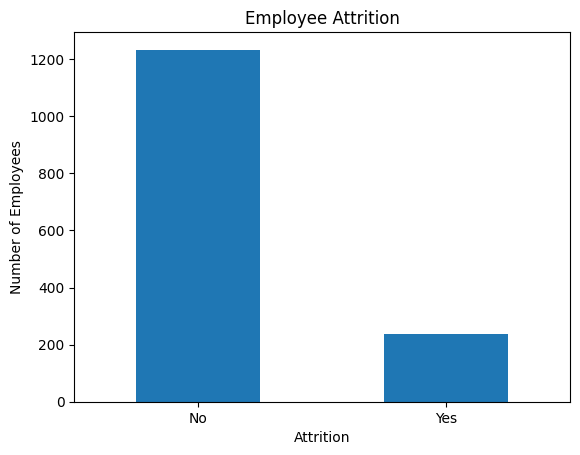

In [ ]:
df['Attrition'].value_counts().plot(kind='bar')
plt.title('Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.show()

# Preprocessing
## Data Preprocessing
An analytical copy was made to preserve a copy of the original data set, and ensure that all transformations made on the data set could be repeated without altering the original data set.
To minimize potential problems with column names in subsequent Pandas operations, the names were cleaned of leading and trailing whitespace. No names were renamed since the names are interpretable for the analysis.
The quality assessment determined that there were no duplicate rows. The duplicate-removal process, however, was retained as a repeatable process in case of accidentally duplicated files due to any modification of the source file (Al-Ali et al., 2026).
In order to ensure that categories that are visually the same are grouped together when performing aggregation, whitespace was removed from categorical fields. This is particularly the case for other variables such as Department, JobRole, BusinessTravel and OverTime, where various text representations may lead to incorrect rates of attrition of subgroups.
DistanceFromHome was recoded to DistanceBand, an interpretable measure of employee segment based on a continuous measure of distance.
The bands are used to compare the observed attrition for different groups of commuting-distances, but the original continuous variable is kept for other analyses. This change is thus not just cosmetic but is of an analytical purpose.

In [ ]:
data = df.copy()

In [ ]:
data.columns = data.columns.str.strip()

In [ ]:
data = data.drop_duplicates().copy()

In [ ]:
for col in data.select_dtypes(include='object'):
    data[col] = data[col].str.strip()

In [ ]:
print("Total missing values:", data.isna().sum().sum())

Total missing values: 0


# Identify the engineered variables

In [ ]:
engineered = [
    'AgeGroup',
    'TenureGroup',
    'MonthlyIncomeBracket',
    'OverallSatisfactionIndex'
]

data[engineered].head()

,AgeGroup,TenureGroup,MonthlyIncomeBracket,OverallSatisfactionIndex
0,35-44,Established (6-10 yrs),High,2.00
1,45-54,Established (6-10 yrs),High,3.00
2,35-44,New (0-2 yrs),Low,3.00
3,25-34,Established (6-10 yrs),Low,3.25
4,25-34,New (0-2 yrs),Medium,2.50


In [ ]:
for col in engineered:
    print(f"\n{col}")
    print(data[col].value_counts(dropna=False))


AgeGroup
AgeGroup
25-34       554
35-44       505
45-54       245
Under 25     97
55+          69
Name: count, dtype: int64

TenureGroup
TenureGroup
Established (6-10 yrs)    448
Early (3-5 yrs)           434
New (0-2 yrs)             342
Veteran (10+ yrs)         246
Name: count, dtype: int64

MonthlyIncomeBracket
MonthlyIncomeBracket
Low          369
Very High    368
High         367
Medium       366
Name: count, dtype: int64

OverallSatisfactionIndex
OverallSatisfactionIndex
2.75    272
3.00    265
2.50    239
2.25    196
3.25    185
3.50    106
2.00     98
1.75     38
3.75     35
1.50     23
4.00      6
1.25      6
1.00      1
Name: count, dtype: int64


# Create a reusable attrition-rate function

In [ ]:
def attrition_by(data, column):
    return (
        data.groupby(column, observed=True)['Attrition']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .round(2)
        .sort_values(ascending=False)
    )

In [ ]:
overall_attrition = (data['Attrition'].eq('Yes').mean() * 100).round(2)

print(f"Overall attrition rate: {overall_attrition}%")

Overall attrition rate: 16.12%


In [ ]:
attrition_by(data, 'Department')

,Attrition
Department,
Sales,20.63
Human Resources,19.05
Research & Development,13.84


# Explanatory Data Analysis
The explanatory analysis goes on to analyze employee attrition with respect to the overall observed employee attrition rate (16.12%). The aim is to determine whether there are notable differences between the sets of employees and whether a combination of workforce factors reveals more interesting differences than do individual workforce factors (Pavithran and Vadivel, 2025). All of these observations in this data are considered “relationships,” not causative.

# BUSINESS QUESTION 1:  How does observed employee attrition differ across departments?
The question becomes important as the Organisation-wide attrition rate could hide the fact that there are significant differences between Business Units. If there is variation across different departments, HR can subsequently look to see if there are retention problems in one particular environment within the organisation.
The analysis showed that the highest attrition percentage was in Sales (20.63%) followed by Human Resources (19.05%) and Research & Development (13.84%). Compared to the overall 16.12% benchmark, Sales was up 4.51 percentage points while R&D was down 2.28 percentage points.
The discovery shows that attrition isn't spread evenly throughout the departments. This may be an important area for further research, particularly regarding job demands, overtime, travel and employee experience (Baydili and Tasci, 2025) . However, it is important to note that department cannot be considered a stand-alone explanation as the job role and working conditions might vary systematically across departments. The conclusion thus would be that it is an area that management should consider as opposed to saying that if an employee has a member of this department, then he or she would leave.

In [ ]:
q1_table = (
    data.groupby('Department')
    .agg(
        Employees=('EmployeeNumber', 'nunique'),
        Leavers=('Attrition', lambda x: x.eq('Yes').sum())
    )
)

q1_table['AttritionRate'] = (
    q1_table['Leavers'] / q1_table['Employees'] * 100
).round(2)

q1_table['DifferenceFromOverall'] = (
    q1_table['AttritionRate'] - overall_attrition
).round(2)

q1_table.sort_values('AttritionRate', ascending=False)

,Employees,Leavers,AttritionRate,DifferenceFromOverall
Department,,,,
Sales,446,92,20.63,4.51
Human Resources,63,12,19.05,2.93
Research & Development,961,133,13.84,-2.28


Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


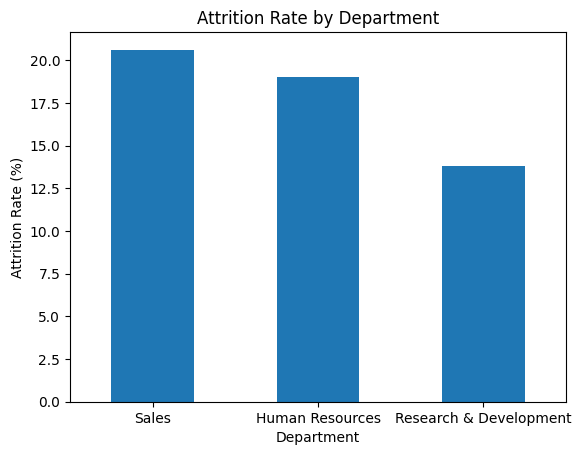

In [ ]:
q1 = attrition_by(data, 'Department')
print(q1)

q1.plot(kind='bar')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

# BUSINESS QUESTION 2: Is overtime associated with higher observed employee attrition?
Overtime is important, as long hours of overtime can be related to workload and working conditions differences. An analysis of retention rates by overtime status thus can provide evidence concerning the association of workload exposure with retention rates.
The observed attrition rate for employees who worked overtime was 30.53% while for those who did not work overtime was 10.44%. This is an pretty massive percentage (20.09%) and indicates a powerful relationship between overtime status and attrition for the knowledge set.
The result shows that overtime needs to be taken more seriously in HR as there is a real difference in the figure compared to the general attrition figure. But, based on this analysis, overtime can't be seen as a causal mechanism (Talebi, Khatibi Bardsiri and Bardsiri, 2025). Overtime workers may be working different roles, different lengths of time or may be travelling or have organisational responsibilities that differ from those of their non- overtime colleagues. Hence, it can best be understood as a priority flag for other analysis to help determine that the decrease in overtime will actually lead to a decrease in attrition.

OverTime
Yes    30.53
No     10.44
Name: Attrition, dtype: float64


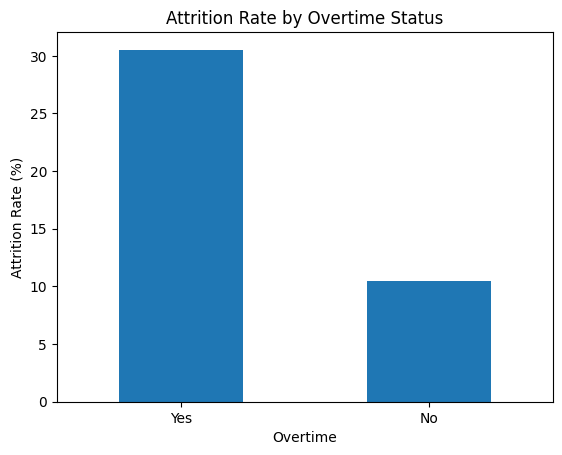

In [ ]:
q2 = attrition_by(data, 'OverTime')
print(q2)

q2.plot(kind='bar')
plt.title('Attrition Rate by Overtime Status')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
pd.crosstab(
    data['OverTime'],
    data['Attrition'],
    normalize='index'
).mul(100).round(2)

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


# BUSINESS QUESTION 3: Which job roles show the highest observed attrition, and how does population size affect interpretation?
Job-role analysis is important because the average for the organisation might mask differences in what people do on a day to day basis. Employee volume, number of leavers and attrition rate are thus analysed as a group.
83 employees were there in Sales Representatives and 33 of them were leavers, which is the maximum attrition rate observed as 39.76%. Laboratory Technicians were next at 23.94% (259 employees and 62 leavers) while Human Resources came up next at 23.08% (52 employees and 12 leavers). Research Directors reported 2.50% on the opposite end with 80 employees and just two leavers.
The comparison illustrates why it is important to not interpret attrition rates without taking into account group size. While the Sales Representatives have the highest rate, the number of leavers is much larger for the Laboratory Technicians due to having significantly more of them employed (Raza et al., 2022). Thus HR should differentiate between the relative exposure to attrition and the absolute impact on the workforce. This gives a more solid foundation for further prioritisation than just percentage ranking.



In [ ]:
q3 = (
    data.groupby('JobRole', observed=True)
    .agg(
        Employees=('EmployeeNumber', 'nunique'),
        Leavers=('Attrition', lambda x: (x == 'Yes').sum())
    )
)

q3['AttritionRate'] = (
    q3['Leavers'] / q3['Employees'] * 100
).round(2)

q3 = q3.sort_values('AttritionRate', ascending=False)

q3

,Employees,Leavers,AttritionRate
JobRole,,,
Sales Representative,83,33,39.76
Laboratory Technician,259,62,23.94
Human Resources,52,12,23.08
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Manufacturing Director,145,10,6.90
Healthcare Representative,131,9,6.87
Manager,102,5,4.90
Research Director,80,2,2.50


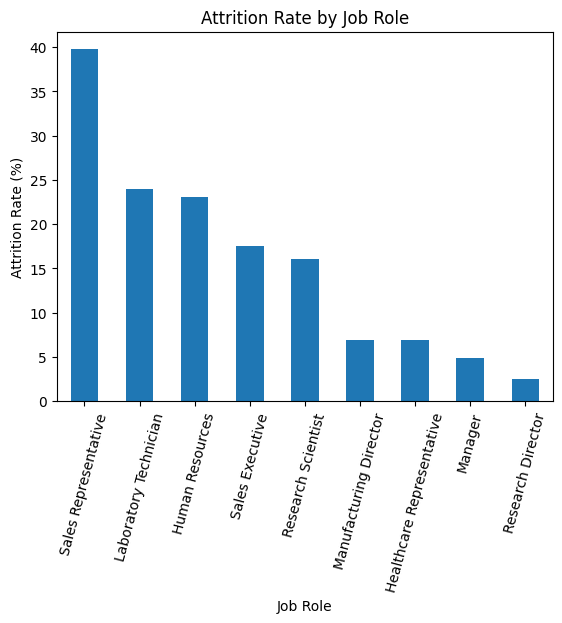

In [ ]:
q3['AttritionRate'].plot(kind='bar')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=75)
plt.show()

# BUSINESS QUESTION 4: How does observed attrition vary across employee tenure groups?
Tenure may be of strategic value because the cost to the organisation due to staff turnover may be significant if employees are departing before they are fully functional in their new role. What the analysis then looks at, is whether there are any consistent differences in the attrition rates as a function of tenure with the organisation.
The attrition rate in the New (0-2 years) group was 29.82% with the Early employees at 13.82%, Established employees at 12.28% and Veterans at 8.13%. Thus, the percentage point difference between the share of New and Veteran employees is 21.69.
It is indicative that a lot of turnover may be happening in the first two years of work. The results show that specific HR activities (onboarding, workload, manager relationship and employee expectations) may be necessary when the employee is in its early years of organisational tenure (Alsheref, Fattoh and Ead, 2022). The downward trend by tenure also allows the inference that attrition observed is lower among employees with longer tenure. But it seems probable that tenure will impact on retention and that the impact of tenure will vary by age and by job level/career progression.


TenureGroup
New (0-2 yrs)             29.82
Early (3-5 yrs)           13.82
Established (6-10 yrs)    12.28
Veteran (10+ yrs)          8.13
Name: Attrition, dtype: float64


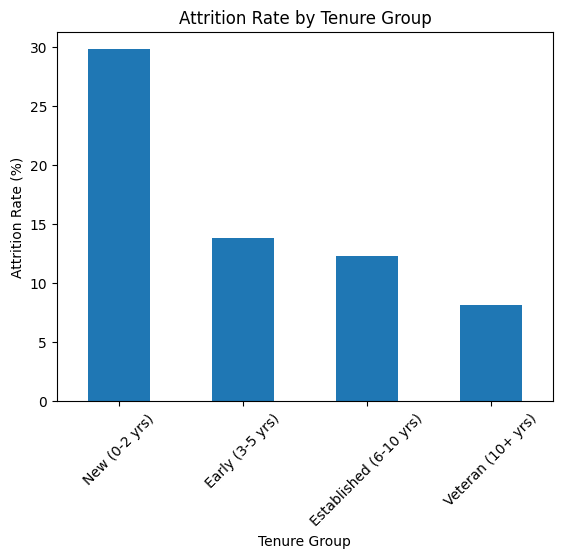

In [ ]:
q4 = attrition_by(data, 'TenureGroup')

print(q4)

q4.plot(kind='bar')
plt.title('Attrition Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
tenure_summary = (
    data.groupby('TenureGroup')
    .agg(
        Employees=('EmployeeNumber', 'count'),
        Leavers=('Attrition', lambda x: (x == 'Yes').sum())
    )
)

tenure_summary['AttritionRate'] = (
    tenure_summary['Leavers'] /
    tenure_summary['Employees'] * 100
).round(2)

tenure_summary

,Employees,Leavers,AttritionRate
TenureGroup,,,
Early (3-5 yrs),434,60,13.82
Established (6-10 yrs),448,55,12.28
New (0-2 yrs),342,102,29.82
Veteran (10+ yrs),246,20,8.13


# BUSINESS QUESTION 5: Are satisfaction measures associated with employee attrition?
Employee satisfaction is relevant because it may be different retention behaviour when employees are satisfied as compared to when they are not. Four dimensions were examined: job satisfaction, environment satisfaction, relationship satisfaction and work-life balance.
Average scores for employees who continued to be recorded were higher on each of the four measures. For the retained employees, the Job Satisfaction score was 2.78 versus 2.47 for leavers and the Environment Satisfaction was 2.77 versus 2.46. For both the difference was: .31 points and this difference was the maximum difference found. The difference for Relationship Satisfaction was 0.13 points and for Work-Life Balance, 0.12 points.
This has remained true, with employees who are leaving reporting less satisfaction, thus confirming that employee experience is a retention factor. The bigger differences in job satisfaction and the environmental satisfaction suggest that these aspects may be studied more than the relationships' satisfaction and work-life balance (Atef, Elzanfaly and Ouf, 2022). Differences in means, however, do not reflect differences in strength or direction of cause and effect and the scales (1-4) should not be interpreted as interval measures of the same.

In [ ]:
# Satisfaction variables
satisfaction_cols = [
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

In [ ]:
satisfaction_summary = (
    data.groupby('Attrition')[satisfaction_cols]
    .mean()
    .round(2)
)

satisfaction_gap = (
    satisfaction_summary.loc['No'] -
    satisfaction_summary.loc['Yes']
).sort_values(ascending=False)

print("Average satisfaction scores:")
display(satisfaction_summary)

print("\nDifference between employees who stayed and left:")
display(satisfaction_gap.round(2))

Average satisfaction scores:


,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance
Attrition,,,,
No,2.78,2.77,2.73,2.78
Yes,2.47,2.46,2.60,2.66



Difference between employees who stayed and left:


,0
EnvironmentSatisfaction,0.31
JobSatisfaction,0.31
RelationshipSatisfaction,0.13
WorkLifeBalance,0.12


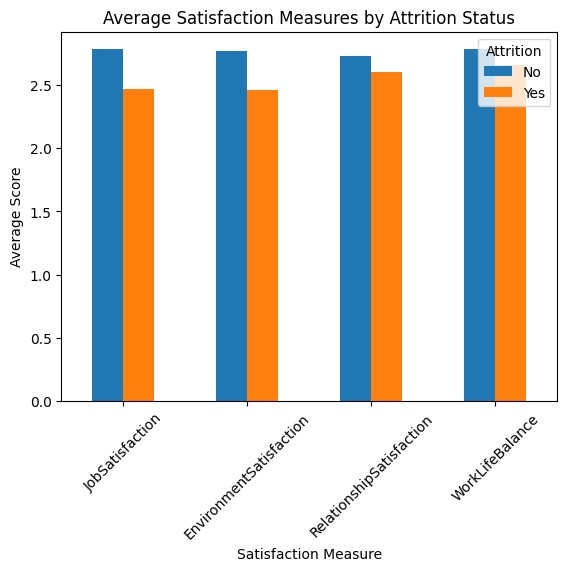

In [ ]:
satisfaction_summary.T.plot(kind='bar')

plt.title('Average Satisfaction Measures by Attrition Status')
plt.xlabel('Satisfaction Measure')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.show()

# BUSINESS QUESTION 6: Is monthly income associated with observed employee attrition?
Compensation is a critical retention dimension as employees at varying levels of income may also be in different organisational and career positions. Hence it is important to analyse income brackets along with mean as well as median monthly incomes.
29.27% of those with low income, 14.21% of those with medium income, 10.63% in the High and 10.33% in the Very High income bracket were experiencing attrition. The difference of percentage points between the lowest and highest income groups (Low and Very High) is 18.94. The mean income during the month for those who stayed (6,832.74) was also higher than the mean income for the employees who left (4,787.09). The median values for these were 5204 and 3202 respectively.
The similarity in the results of the categorical and the numerical analysis indicates that it is important to further study the responses of lower income employees. Income is however highly correlated with occupation and occupation with role/experience, and the observed relationship may identify a number of factors. Therefore, compensation should be considered as a factor related to employment and not as a determining factor.


MonthlyIncomeBracket
Low          29.27
Medium       14.21
High         10.63
Very High    10.33
Name: Attrition, dtype: float64


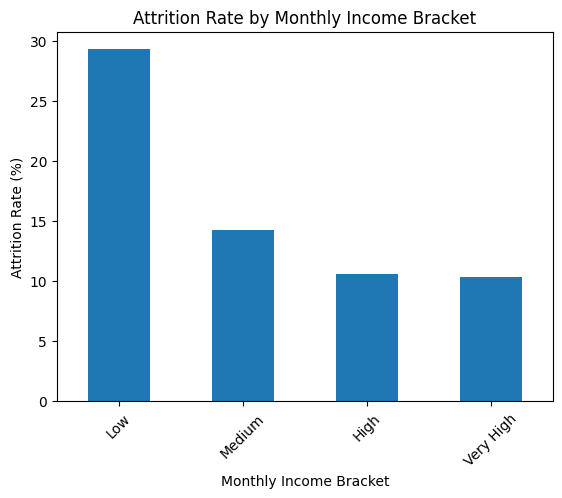

In [ ]:
q6 = attrition_by(data, 'MonthlyIncomeBracket')

print(q6)

q6.plot(kind='bar')
plt.title('Attrition Rate by Monthly Income Bracket')
plt.xlabel('Monthly Income Bracket')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
income_summary = (
    data.groupby('Attrition')['MonthlyIncome']
    .agg(['count', 'mean', 'median'])
    .round(2)
)

income_summary

,count,mean,median
Attrition,,,
No,1233,6832.74,5204.0
Yes,237,4787.09,3202.0


# BUSINESS QUESTION 7: How do career-tenure measures differ between employees who stayed and those who left?
The organisational tenure is a partial concept of retention, career progression is a more comprehensive concept of retention. The analysis is done by year at the company, year in the current job, year since last promotion and year since hired by current manager.
The average tenure for staff remained was 7.37 years while it is 5.13 years for leavers. The average was 4.48 years, but was 2.90 years for the non-participants, and 4.37 years versus 2.85 years in years with the current manager. That's not that big a disparity when compared to the difference in the number of years since last promotion was 2.23 years versus 1.95 years.
Job separation was associated with a shorter tenure in the organisation, role and manager in these results. One important question that the relatively small time difference since promotion does not allow to consider the time since promotion as an explanation for attrition is an overly simplistic one. Instead, it seems that further studies in relation to organisational attachment and role tenure are warranted.


In [ ]:
career_cols = [
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

career_summary = (
    data.groupby('Attrition')[career_cols]
    .mean()
    .round(2)
)

career_summary

,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Attrition,,,,
No,7.37,4.48,2.23,4.37
Yes,5.13,2.90,1.95,2.85


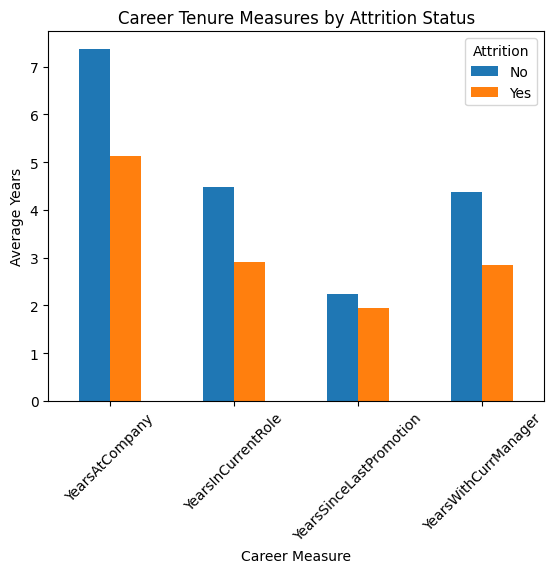

In [ ]:
career_summary.T.plot(kind='bar')

plt.title('Career Tenure Measures by Attrition Status')
plt.xlabel('Career Measure')
plt.ylabel('Average Years')
plt.xticks(rotation=45)
plt.show()

# BUSINESS QUESTION 8:  Does the relationship between overtime and attrition vary by employee tenure?
The overtime question is expanded to see if the relationship with attrition is different for each tenure group. This type of interaction analysis is helpful because a general average may not identify specific groups of employees at higher risk.
In the case of New employees, the difference is 30.37 percentage points between 20.59% with no overtime and 50.96% with overtime. The differences were 20.53 points for Early employees, 18.51 points for Established employees and just 3.59 points for Veterans.
The results suggest that for not all tenure groups overtime is necessarily a negative factor in the prediction of attrition. The largest difference is found between the employed after two years and the employed after one year, indicating that there is a significant overlap between early employment and additional employment. This is more informative than the comparison between the overtime in general since it provides HR with a targeted segment to investigate (Nassreddine et al., 2026). However the analysis is descriptive and does not determine if the difference is due to overtime, tenure or another factor that is correlated.


BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition, dtype: float64


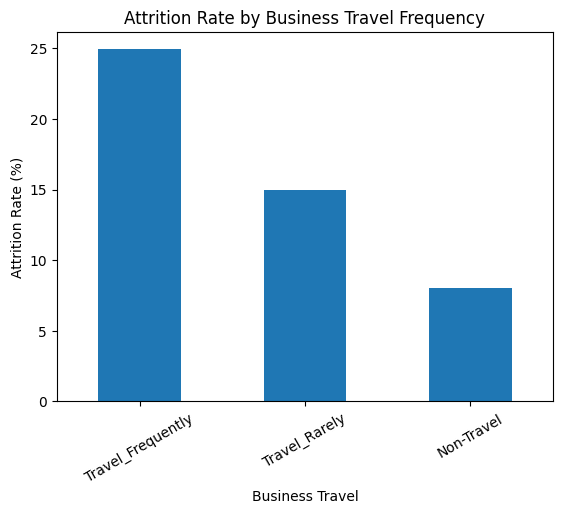

In [ ]:
q8 = attrition_by(data, 'BusinessTravel')

print(q8)

q8.plot(kind='bar')
plt.title('Attrition Rate by Business Travel Frequency')
plt.xlabel('Business Travel')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=30)
plt.show()

In [ ]:
travel_overtime = pd.crosstab(
    [data['BusinessTravel'], data['OverTime']],
    data['Attrition'],
    normalize='index'
).mul(100).round(2)

travel_overtime

Attrition                      No    Yes
BusinessTravel    OverTime              
Non-Travel        No        95.65   4.35
                  Yes       80.00  20.00
Travel_Frequently No        82.72  17.28
                  Yes       58.14  41.86
Travel_Rarely     No        90.37   9.63
                  Yes       71.53  28.47

# BUSINESS QUESTION 9: Is commuting distance associated with observed employee attrition?
To see if attrition is different for different distance groups, the commuting distance was analysed. In order to be compared, DistanceFromHome was broken down into four bands. Employees living 21+ units from work recorded the highest observed attrition at 22.06%, followed by 11–20 (20.00%), 6–10 (14.47%) and 0–5 (13.77%). The gap between the best and worst groups is 8.29 percentage points, which shows that there is a relationship between the increase in commuting distance and the observed attrition (Narkbunnum and Hinthaw, 2025) . But this relationship is weaker than those of overtime and tenure and may be related to other job attributes like job role, income and travel requirements. Distance will therefore be viewed as a contextual retention indicator, which needs to be investigated.

DistanceBand
21+      22.06
11-20    20.00
6-10     14.47
0-5      13.77
Name: Attrition, dtype: float64


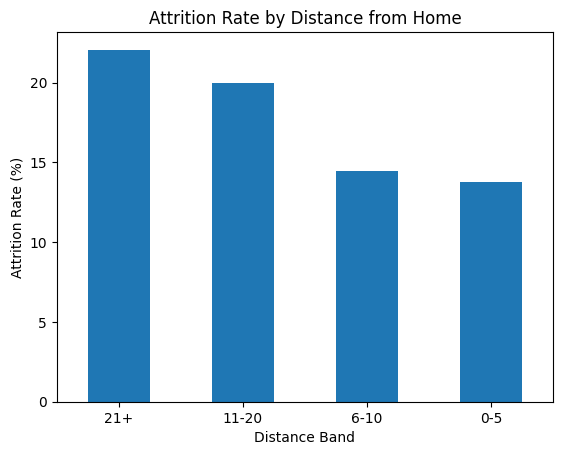

In [ ]:
data['DistanceBand'] = pd.cut(
    data['DistanceFromHome'],
    bins=[0, 5, 10, 20, np.inf],
    labels=['0-5', '6-10', '11-20', '21+']
)

q9 = attrition_by(data, 'DistanceBand')

print(q9)

q9.plot(kind='bar')
plt.title('Attrition Rate by Distance from Home')
plt.xlabel('Distance Band')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

# BUSINESS QUESTION 10: Does the combination of business travel and overtime identify employee groups with particularly high observed attrition?
This analysis investigates if there are stronger attrition patterns revealed by combining business travel and overtime. Employees who travel frequently and are NOT on overtime (17.28%) have the highest attrition rate, followed by employees who frequently travel and are on overtime (41.86%). With overtime, the attrition rate for employees travelling is 28.47% and without overtime, it is 9.63% (Pöppel, Schiller and Weinfurtner, 2026). The rates for non-travellers is 20.00% and 4.35%. Results indicate that demanding working conditions may be worthy of studying jointly; and that the frequent travelling and overtime group is one that should be studied. It is important to remember that these associations do not necessarily mean causation.

In [ ]:
q10 = pd.pivot_table(
    data,
    values='Attrition',
    index='TenureGroup',
    columns='OverTime',
    aggfunc=lambda x: (x == 'Yes').mean() * 100
).round(2)

q10

OverTime,No,Yes
TenureGroup,,
Early (3-5 yrs),7.82,28.35
Established (6-10 yrs),7.32,25.83
New (0-2 yrs),20.59,50.96
Veteran (10+ yrs),7.18,10.77


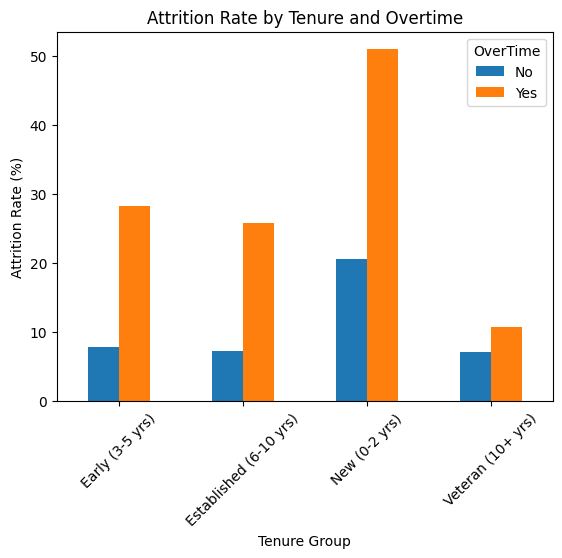

In [ ]:
q10.plot(kind='bar')

plt.title('Attrition Rate by Tenure and Overtime')
plt.xlabel('Tenure Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.show()

# Integrated analysis

# Integrated Findings and Business Implications
It's found that employee attrition is not homogenous from every employee. Overtime, early organisational tenure, lower income, selected job roles and frequent business travel are observed attrition factors that have higher rates than the overall benchmark rate of 16.12%. The best single patterns are overtime (30.53%) and New (0-2 years) tenure group (29.82%). Additionally, the satisfaction level is lower for leavers and Job Satisfaction and Environment Satisfaction on average 0.31 points lower than for those who remained.
The overall analysis provides a more specific view. The difference between the percentages of New employees who are working overtime and those who are not working overtime is 50.96% - 20.59% = 30.37 percentage points. The same is true of those who travel often, the attrition rate is 41.86% when overtime is also involved. The findings indicate that retention analysis should be done taking into account not only the individual employee characteristics, but also the combination of working conditions.
The outcomes indicated that there may be a need for an organisation-wide recruitment and retention strategy to be replaced with more than one when considering ABC Global Services. HR should focus more on the in-depth study of early employees who are subjected to challenging working conditions, as well as on studying patterns of satisfaction, compensation and roles (Galindo, Karam and Gomez, 2026). Any observed association does not imply causality and only the results are shown for targeted decision-making.


In [ ]:
key_variables = [
    'OverTime',
    'BusinessTravel',
    'JobLevel',
    'JobSatisfaction',
    'WorkLifeBalance',
    'MonthlyIncome',
    'YearsAtCompany',
    'DistanceFromHome'
]

data.groupby('Attrition')[key_variables].mean(numeric_only=True).round(2)

,JobLevel,JobSatisfaction,WorkLifeBalance,MonthlyIncome,YearsAtCompany,DistanceFromHome
Attrition,,,,,,
No,2.15,2.78,2.78,6832.74,7.37,8.92
Yes,1.64,2.47,2.66,4787.09,5.13,10.63


In [ ]:
for col in ['OverTime', 'BusinessTravel', 'JobLevel']:
    print(f"\n{col}")
    print(pd.crosstab(
        data[col],
        data['Attrition'],
        normalize='index'
    ).mul(100).round(2))


OverTime
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53

BusinessTravel
Attrition             No    Yes
BusinessTravel                 
Non-Travel         92.00   8.00
Travel_Frequently  75.09  24.91
Travel_Rarely      85.04  14.96

JobLevel
Attrition     No    Yes
JobLevel               
1          73.66  26.34
2          90.26   9.74
3          85.32  14.68
4          95.28   4.72
5          92.75   7.25


# Critical Evaluation and Limitations
Although an analysis provides useful explanatory evidence, it may not be foolproof. Initially, there are only found relatedness, not necessarily causedness; the high percent employees who work overtime or earn less have high attrition, not necessarily because of overtime or low income. Secondly, the data is fictional, and can only be directly generalised to ABC Global Services or other organizations. Third, because of its cross-sectional design, it does not make any statements about the temporal order of employee conditions and attrition. Fourth, there are likely to be systematic relationships among income, job level, role, tenure, overtime and travel, that is, they are likely to be confounded and interdependent. Finally, there are engineered variables for AgeGroup, TenureGroup, MonthlyIncomeBracket and OverallSatisfactionIndex which are given in the improved data. Understanding the construction might require considering how such patterns are affected by the observed variables (Park, Feng and Jeong, 2024). Therefore, the results should be used to prioritized HR investigations, but not to make causal interventions.
# Data-Driven Recommendations
#### 1.	On-boarding focus on early-tenure retention analysis: Early evidence of high attrition rate (29.82%) with New employees – onboarding, workload and manager support.
#### 2.	Overtime exposure: employees working overtime have 30.53% attrition, while those not have 10.44% attrition. HR should focus on workload distribution and overtime focus.
#### 3.	Combined-risk segments: New employees working overtime have a 50.96% observed attrition. This segment is an area that should be explored, but not kept in its entirety.
#### 4.	Review Compensation Trend: The attrition rate of the Low income group is 29.27% and the compensation needs to be reviewed based on Job Level & Job role.
#### 5.	Monitor employee experience: The largest difference found between employees that stay and those that leave is Job Satisfaction and Environment Satisfaction (0.31 points).
# Conclusion
The explanatory analysis reveals that there are significant differences in the observed employee attrition and the most prominent differences are related to overtime, early tenure, compensation, satisfaction and specific job roles. Specifically, 50.96% of New employees that are working overtime are at risk for attrition, and 20.59% of New employees not working overtime are at risk for attrition. This interaction helps them to have a more robust base for HR prioritisation than organisation-wide attrition alone. The results validate the need to target labor force segments with poor working conditions, and show that descriptive data do not allow causal explanations. These findings should thus be taken by ABC Global Services as a starting point to focus retention analysis, design interventions and monitor these interventions in the future and not as a definitive explanation of employee departure.



# References

##### Al-Ali, M., Alwateer, M., Alsaedi, S.A., Balaha, H.M., Badawy, M. and A. Elhosseini, M., 2026. Integrating machine learning and explainable AI for employee attrition prediction in HR analytics: M. AL-Ali et al. Scientific Reports, 16(1), p.6344.
##### Alsheref, F.K., Fattoh, I.E. and M. Ead, W., 2022. Automated prediction of employee attrition using ensemble model based on machine learning algorithms. Computational Intelligence and Neuroscience, 2022(1), p.7728668.
##### Atef, M., S Elzanfaly, D. and Ouf, S., 2022. Early prediction of employee turnover using machine learning algorithms. International journal of electrical and computer engineering systems, 13(2), pp.135-144.
##### Baydili, İ.T. and Tasci, B., 2025. Predicting employee attrition: XAI-powered models for managerial decision-making. Systems, 13(7), p.583.
##### Galindo, J.C.R., Karam, J.P.P. and Gomez, G.S., 2026. Applying HR Analytics to Employee Turnover: Evidence from the IT Sector in Guadalajara, Mexico. International Journal of Computer Information Systems and Industrial Management Applications, 18(6s), pp.430-440.
##### Kamaruzzaman, Z.A., Tan, Y.P. and Kamaruzzaman, Z.A., 2025. Predicting the employee turnover intention: How organizations leverage data-driven HR predictive analytics for talent management decision-making. Journal of Human Capital Development (JHCD), 18(1), pp.56-81.
##### Marín Díaz, G., Galán Hernández, J.J. and Galdón Salvador, J.L., 2023. Analyzing employee attrition using explainable AI for strategic HR decision-making. Mathematics, 11(22), p.4677.
##### Narkbunnum, W. and Hinthaw, K., 2025. Interpretable gradient boosted modeling of employee attrition: A SHAP-based framework for HR analytics. International Journal of Analysis and Applications, 23, pp.236-236.
##### Nassreddine, G., Hammoud, J., Al-Khatib, O. and Majzoub, M.A., 2026. Employee attrition prediction: an explanatory and statistically robust ensemble learning model. Computers, 15(3), p.185.
##### Neelisetty, L.S., Bonthu, N.P.R. and Jukuntla, A., Early Detection of Employee Turnover Risks Using Machine Learning Approaches. Proceedings Copyright, 119, p.128.
##### Park, J., Feng, Y. and Jeong, S.P., 2024. Developing an advanced prediction model for new employee turnover intention utilizing machine learning techniques. Scientific reports, 14(1), p.1221.
##### Pavithran, M.S. and Vadivel, S.M., 2025. Explainable attrition risk scoring for managerial retention decisions in human resource analytics. Frontiers in big Data, 8, p.1699561.
##### Pöppel, E., Schiller, A. and Weinfurtner, L., 2026. Analyzing voluntary employee turnover: A data-driven explanatory modeling approach. Decision Support Systems, p.114713.
##### Raza, A., Munir, K., Almutairi, M., Younas, F. and Fareed, M.M.S., 2022. Predicting employee attrition using machine learning approaches. Applied Sciences, 12(13), p.6424.
##### Talebi, H., Khatibi Bardsiri, A. and Bardsiri, V.K., 2025. Machine learning approaches for predicting employee turnover: A systematic review. Engineering Reports, 7(8), p.e70298.

